<a href="https://colab.research.google.com/github/vikashkumar97983282-glitch/Deep_Learning/blob/main/IPL_DataSet_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print('hello world')

hello world


In [ ]:
# select the GPU
# import tensorflow as tf

# resolver = tf.distribute.cluster_resolver.TPUClusterResolver()
# tf.config.experimental_connect_to_cluster(resolver)
# tf.tpu.experimental.initialize_tpu_system(resolver)

# strategy = tf.distribute.TPUStrategy(resolver)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('IPL.csv')

/tmp/ipykernel_14750/418616701.py:1: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('IPL.csv')


In [ ]:
df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [ ]:
features = [
    'batting_team',
    'bowling_team',
    'venue',
    'city',
    'toss_winner',
    'toss_decision',
    'over',
    'team_runs',
    'team_wicket',
    'runs_target',
    'stage',
    'match_won_by'
]

In [ ]:
df = df[features]

In [ ]:
df.shape

(283678, 12)

In [ ]:
df.duplicated().sum()

np.int64(70773)

In [ ]:
df = df.drop_duplicates(df.columns)

In [ ]:
df.isnull().sum()

,0
batting_team,0
bowling_team,0
venue,0
city,0
toss_winner,0
toss_decision,0
over,0
team_runs,0
team_wicket,0
runs_target,110751


In [ ]:
df['runs_target'] = df['runs_target'].fillna(df['runs_target'].mean())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212905 entries, 0 to 283677
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   batting_team   212905 non-null  object 
 1   bowling_team   212905 non-null  object 
 2   venue          212905 non-null  object 
 3   city           212905 non-null  object 
 4   toss_winner    212905 non-null  object 
 5   toss_decision  212905 non-null  object 
 6   over           212905 non-null  int64  
 7   team_runs      212905 non-null  int64  
 8   team_wicket    212905 non-null  int64  
 9   runs_target    212905 non-null  float64
 10  stage          212905 non-null  object 
 11  match_won_by   212905 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 21.1+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
cols = ['batting_team', 'bowling_team', 'venue', 'city', 'toss_winner', 'toss_decision', 'stage', 'match_won_by']

for col in cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,batting_team,bowling_team,venue,city,toss_winner,toss_decision,over,team_runs,team_wicket,runs_target,stage,match_won_by
0,8,16,23,2,16,1,0,1,0,171.470231,7,8
2,8,16,23,2,16,1,0,2,0,171.470231,7,8
6,8,16,23,2,16,1,0,3,0,171.470231,7,8
7,8,16,23,2,16,1,1,3,0,171.470231,7,8
8,8,16,23,2,16,1,1,7,0,171.470231,7,8


<Axes: >

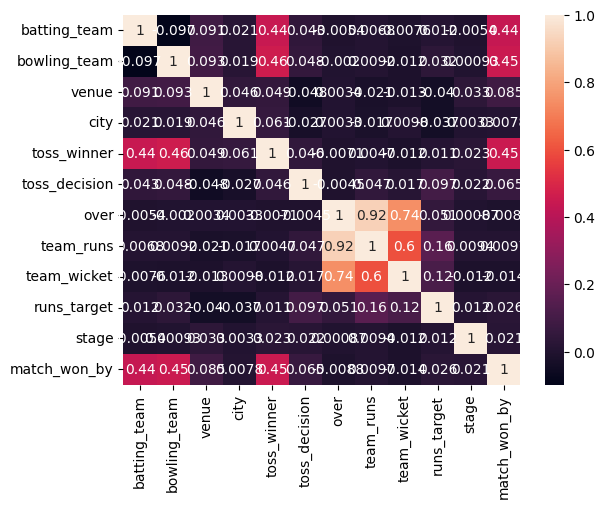

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212905 entries, 0 to 283677
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   batting_team   212905 non-null  int64  
 1   bowling_team   212905 non-null  int64  
 2   venue          212905 non-null  int64  
 3   city           212905 non-null  int64  
 4   toss_winner    212905 non-null  int64  
 5   toss_decision  212905 non-null  int64  
 6   over           212905 non-null  int64  
 7   team_runs      212905 non-null  int64  
 8   team_wicket    212905 non-null  int64  
 9   runs_target    212905 non-null  float64
 10  stage          212905 non-null  int64  
 11  match_won_by   212905 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 21.1 MB


In [ ]:
df = df.astype(int)

In [ ]:
X = df.drop('match_won_by',axis=1)
y = df['match_won_by']

In [ ]:
y.head()

,match_won_by
0,8
2,8
6,8
7,8
8,8


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [ ]:
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:
X_train_scaled.shape

(170324, 11)

In [ ]:
y_train.value_counts()

,count
match_won_by,
10,21562
0,20979
8,18833
13,17032
16,15894
18,13854
6,12059
3,9327
2,7799


In [ ]:
y_test_en = to_categorical(y_test,num_classes=20)
y_train_en = to_categorical(y_train,num_classes=20)

In [ ]:
y_train_en.shape

(170324, 20)

In [ ]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=11))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(20,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history = model.fit(X_train_scaled,y_train_en,epochs=100,batch_size=32,verbose=1,validation_data=(X_test_scaled,y_test_en))

Epoch 1/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.5719 - loss: 1.2929 - val_accuracy: 0.7258 - val_loss: 0.8032
Epoch 2/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.7764 - loss: 0.6285 - val_accuracy: 0.8142 - val_loss: 0.5188
Epoch 3/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8455 - loss: 0.4309 - val_accuracy: 0.8709 - val_loss: 0.3691
Epoch 4/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.8767 - loss: 0.3407 - val_accuracy: 0.8948 - val_loss: 0.2907
Epoch 5/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.8941 - loss: 0.2914 - val_accuracy: 0.8995 - val_loss: 0.2944
Epoch 6/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9072 - loss: 0.2589 - val_accuracy: 0.9075 - val_loss: 0.2540
Epoch 7/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9145 - loss: 0.2367 - val_accuracy: 0.9291 - val_loss: 0.1967
Epoch 8/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9212 -

In [ ]:
loss,accuracy = model.evaluate(X_test_scaled,y_test_en,verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy*100:.2f}%')

Test Loss: 0.0815
Test Accuracy: 97.19%


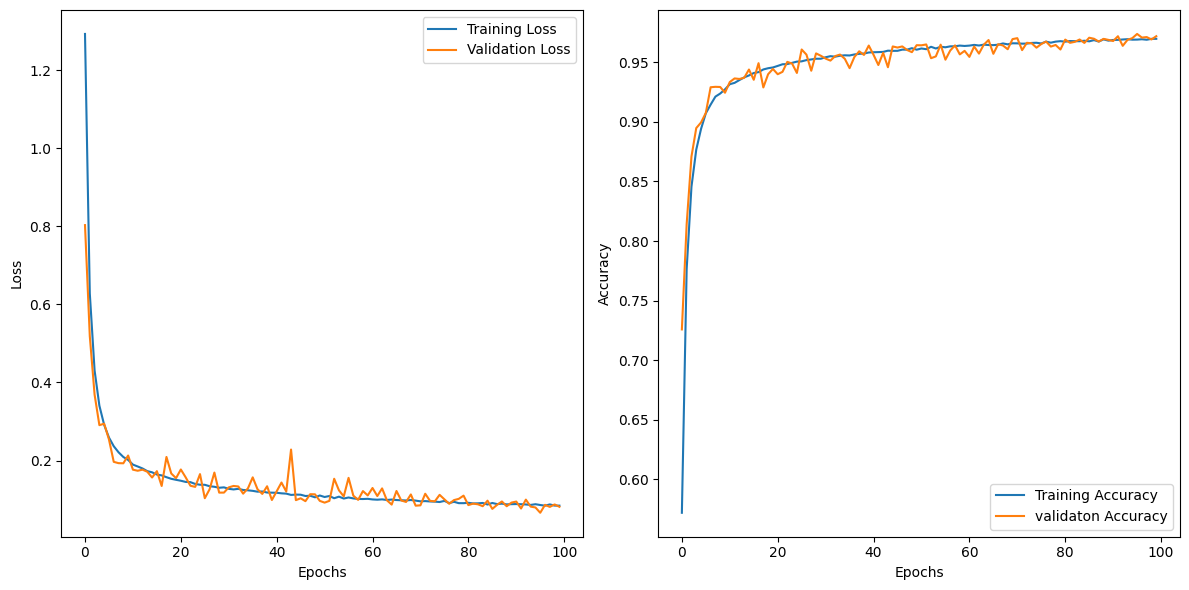

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validaton Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()



In [ ]:
# callbacks er
callbacks = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=3,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [ ]:
history = model.fit(X_train_scaled,y_train_en,epochs=100,batch_size=32,verbose=1,validation_data=(X_test_scaled,y_test_en),callbacks=[callbacks])

Epoch 1/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.7346 - loss: 0.7532 - val_accuracy: 0.7722 - val_loss: 0.6329
Epoch 2/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8197 - loss: 0.5020 - val_accuracy: 0.8533 - val_loss: 0.4193
Epoch 3/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8603 - loss: 0.3849 - val_accuracy: 0.8704 - val_loss: 0.3373
Epoch 4/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8842 - loss: 0.3178 - val_accuracy: 0.8985 - val_loss: 0.2762
Epoch 5/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.8964 - loss: 0.2824 - val_accuracy: 0.9107 - val_loss: 0.2529
Epoch 6/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9089 - loss: 0.2501 - val_accuracy: 0.9112 - val_loss: 0.2475
Epoch 7/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9157 - loss: 0.2335 - val_accuracy: 0.9265 - val_loss: 0.1998
Epoch 8/100
5323/5323 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9200 -

In [ ]:
loss,accuracy = model.evaluate(X_test_scaled,y_test_en,verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy*100:.2f}%')

Test Loss: 0.1684
Test Accuracy: 93.99%


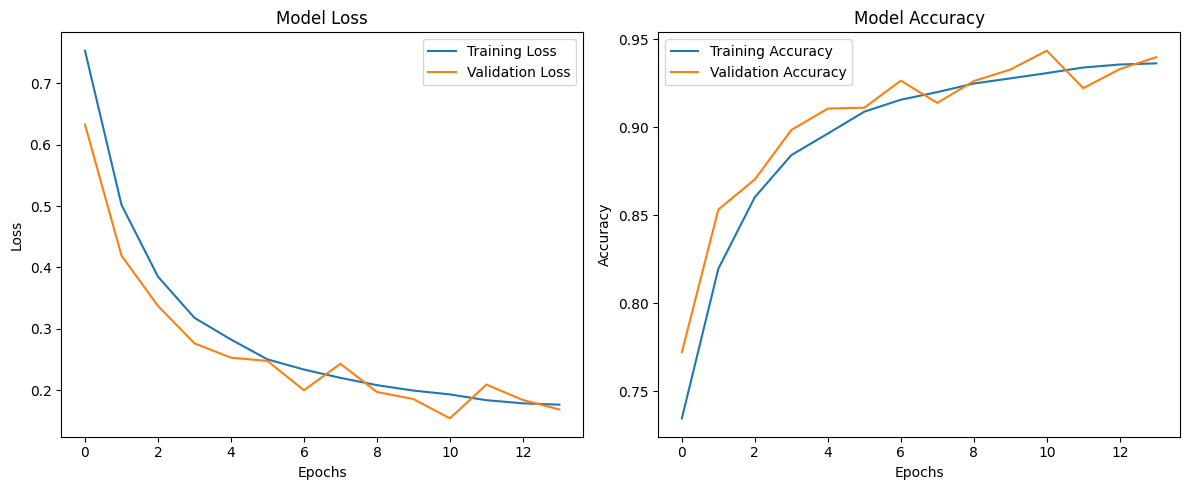

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.tight_layout()
plt.show()